In [1]:
pip install tensorflow keras opencv-python scikit-image imutils

In [6]:
# Required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt


def order_points(pts):
    """
    Points ko order karta hai:
    top-left, top-right, bottom-right, bottom-left
    """
    rect = np.zeros((4, 2), dtype="float32")

    # Sum of points (x + y)
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]  # Top-left
    rect[2] = pts[np.argmax(s)]  # Bottom-right

    # Difference (x - y)
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]  # Top-right
    rect[3] = pts[np.argmax(diff)]  # Bottom-left

    return rect


def four_point_transform(image, pts):
    """
    Image ka perspective transform karta hai
    """
    rect = order_points(pts)
    (tl, tr, br, bl) = rect

    # Width calculate karo
    widthA = np.linalg.norm(br - bl)
    widthB = np.linalg.norm(tr - tl)
    maxWidth = max(int(widthA), int(widthB))

    # Height calculate karo
    heightA = np.linalg.norm(tr - br)
    heightB = np.linalg.norm(tl - bl)
    maxHeight = max(int(heightA), int(heightB))

    # Destination points (output image ke corners)
    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]
    ], dtype="float32")

    # Perspective transform matrix
    M = cv2.getPerspectiveTransform(rect, dst)

    # Warp image
    warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))

    return warped

In [7]:
import cv2
import numpy as np

def deskew(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.bitwise_not(gray)

    thresh = cv2.threshold(
        gray, 0, 255,
        cv2.THRESH_BINARY | cv2.THRESH_OTSU
    )[1]

    coords = np.column_stack(np.where(thresh > 0))
    angle = cv2.minAreaRect(coords)[-1]

    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle

    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)

    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    rotated = cv2.warpAffine(
        image, M, (w, h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE
    )

    return rotated, angle

Saving rafia oop1.png to rafia oop1.png


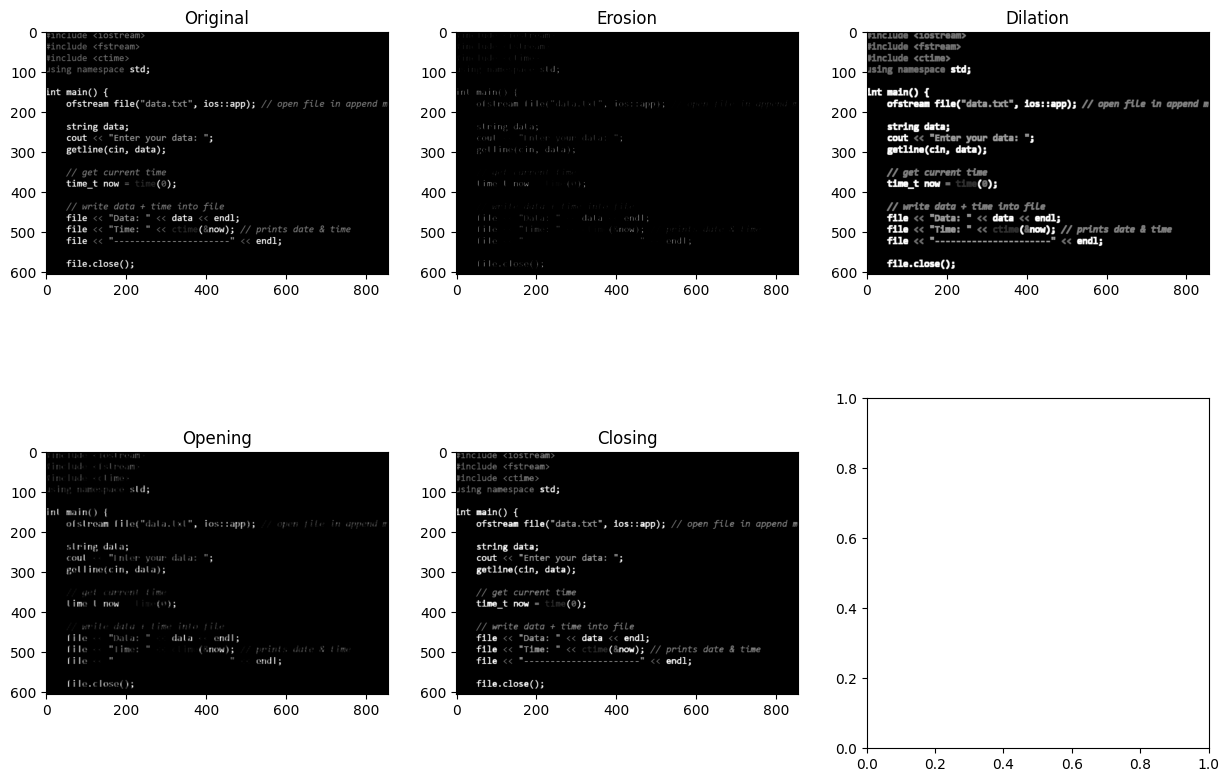

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]

img = cv2.imread(filename)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

kernel = np.ones((3, 3), np.uint8)

erosion = cv2.erode(gray, kernel, iterations=1)
dilation = cv2.dilate(gray, kernel, iterations=1)

opening = cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, kernel)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(gray, cmap='gray')
axes[0, 0].set_title('Original')

axes[0, 1].imshow(erosion, cmap='gray')
axes[0, 1].set_title('Erosion')

axes[0, 2].imshow(dilation, cmap='gray')
axes[0, 2].set_title('Dilation')

axes[1, 0].imshow(opening, cmap='gray')
axes[1, 0].set_title('Opening')

axes[1, 1].imshow(closing, cmap='gray')
axes[1, 1].set_title('Closing')

plt.show()

In [11]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"Training samples: {x_train.shape[0]}")
print(f"Test samples: {x_test.shape[0]}")
print(f"Image shape: {x_train.shape[1:]}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 60000
Test samples: 10000
Image shape: (28, 28)


In [12]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [13]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.1
)

test_loss, test_acc = model.evaluate(x_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 100ms/step - accuracy: 0.8995 - loss: 0.3211 - val_accuracy: 0.9823 - val_loss: 0.0612
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 100ms/step - accuracy: 0.9694 - loss: 0.1025 - val_accuracy: 0.9875 - val_loss: 0.0441
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 101ms/step - accuracy: 0.9767 - loss: 0.0776 - val_accuracy: 0.9880 - val_loss: 0.0391
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 101ms/step - accuracy: 0.9812 - loss: 0.0623 - val_accuracy: 0.9888 - val_loss: 0.0372
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 100ms/step - accuracy: 0.9841 - loss: 0.0526 - val_accuracy: 0.9885 - val_loss: 0.0373
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 101ms/step - accuracy: 0.9866 - loss: 0.0463 - val_accuracy: 0.9900 - val_loss: 0.0363
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 85s 109ms/step - accuracy: 0.9875 - loss: 0.0405 - val_accuracy: 0.9905 - val_loss: 0.0348
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 79s 103ms/step - accuracy: 0.9894 - loss: 0